In [1]:
import pandas as pd
import altair as alt
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [2]:
data = pd.read_csv('Absenteeism_at_work.csv',sep=';')

In [3]:
data.head()

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,Hit target,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26,7,3,1,289,36,13,33,239.554,97,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,239.554,97,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,239.554,97,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,239.554,97,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,239.554,97,0,1,2,1,0,1,90,172,30,2


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
ID                                 740 non-null int64
Reason for absence                 740 non-null int64
Month of absence                   740 non-null int64
Day of the week                    740 non-null int64
Seasons                            740 non-null int64
Transportation expense             740 non-null int64
Distance from Residence to Work    740 non-null int64
Service time                       740 non-null int64
Age                                740 non-null int64
Work load Average/day              740 non-null float64
Hit target                         740 non-null int64
Disciplinary failure               740 non-null int64
Education                          740 non-null int64
Son                                740 non-null int64
Social drinker                     740 non-null int64
Social smoker                      740 non-null int64
Pet                          

Notice how most of the relevant time-related variables are in integer format.

In [5]:
data.isnull().sum()

ID                                 0
Reason for absence                 0
Month of absence                   0
Day of the week                    0
Seasons                            0
Transportation expense             0
Distance from Residence to Work    0
Service time                       0
Age                                0
Work load Average/day              0
Hit target                         0
Disciplinary failure               0
Education                          0
Son                                0
Social drinker                     0
Social smoker                      0
Pet                                0
Weight                             0
Height                             0
Body mass index                    0
Absenteeism time in hours          0
dtype: int64

Data is already cleaned, as this was downloaded from UCI repository. <br>

Now, let us start exploring the dataset. Interactive plots helps with the Exploratory Data Analysis Process, because it is easier to see how each variables affects the other.

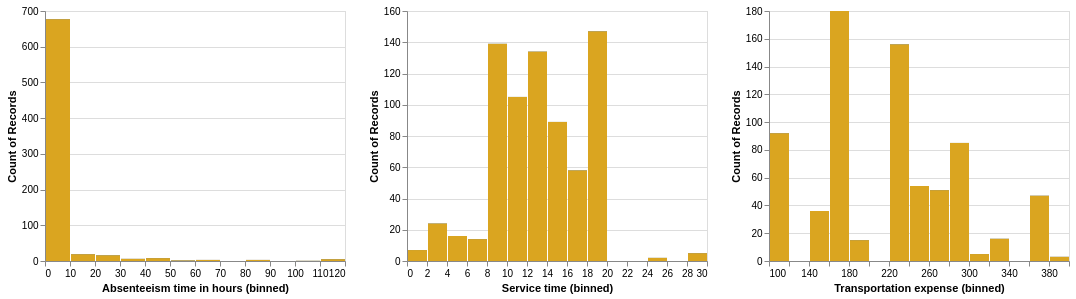

In [10]:

brush = alt.selection(type='interval', encodings=['x'])

base = alt.Chart().mark_bar().encode(
    x=alt.X(alt.repeat('column'), type='quantitative', bin=alt.Bin(maxbins=20)),
    y='count()'
).properties(
    width=300,
    height=250
)


background = base.add_selection(brush)


highlight = base.encode(
    color=alt.value('goldenrod')
).transform_filter(brush)

# layer the two charts & repeat
chart = alt.layer(
    background,
    highlight,
    data=data
).repeat(column=['Absenteeism time in hours','Service time','Transportation expense'])
chart

In [7]:
import ipywidgets as widgets
from ipywidgets import interact, interact_manual

In [8]:
data = pd.read_csv('Absenteeism_at_work.csv',sep=';')
@interact
def get_col(Feature1=list(data.select_dtypes('number').columns),
            Feature2=list(data.select_dtypes('number').columns),
            Feature3=list(data.select_dtypes('number').columns),):
    cols = []
    cols.append(Feature1)
    cols.append(Feature2)
    cols.append(Feature3)
    if len(cols) != len(set(cols)):
        feature_list = ['Absenteeism time in hours','Service time','Transportation expense']
    else:
        feature_list = cols
    
    brush = alt.selection(type='interval', encodings=['x'])

    base = alt.Chart().mark_bar().encode(
        x=alt.X(alt.repeat('column'), type='quantitative', bin=alt.Bin(maxbins=20)),
        y='count()'
    ).properties(
        width=300,
        height=250
    )


    background = base.add_selection(brush)


    highlight = base.encode(
        color=alt.value('goldenrod')
    ).transform_filter(brush)

    # layer the two charts & repeat
    chart = alt.layer(
        background,
        highlight,
        data=data
    ).repeat(column = feature_list)
    return chart

interactive(children=(Dropdown(description='Feature1', options=('ID', 'Reason for absence', 'Month of absence'…

In [11]:
# import nbinteract as nbi
# nbi.publish('benjcabalona1029/benjcabalona1029.github.io/master', 'Analysis.ipynb')